## Lab 2

### Part 3. Poetry generation

Let's try to generate some poetry using RNNs.

You have several choices here:

* The Shakespeare sonnets, file `sonnets.txt` available in the notebook directory.

* Роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина. В предобработанном виде доступен по [ссылке](https://github.com/attatrol/data_sources/blob/master/onegin.txt).

* Some other text source, if it will be approved by the course staff.

Text generation can be designed in several steps:
    
1. Data loading.
2. Dictionary generation.
3. Data preprocessing.
4. Model (neural network) training.
5. Text generation (model evaluation).


In [2]:
import string
import os

### Data loading: Shakespeare

Shakespeare sonnets are awailable at this [link](http://www.gutenberg.org/ebooks/1041?msg=welcome_stranger). In addition, they are stored in the same directory as this notebook (`sonnetes.txt`). Simple preprocessing is already done for you in the next cell: all technical info is dropped.

In [3]:
!rm -f sonnets.txt
if not os.path.exists('sonnets.txt'):
    #!wget https://raw.githubusercontent.com/girafe-ai/ml-course/22f_basic/homeworks_basic/lab02_deep_learning/sonnets.txt
    !wget https://raw.githubusercontent.com/gammabox2020/ml-course-2023-homeworks/23f_basic/homeworks/lab02_deep_learning/sonnets.txt

with open('sonnets.txt', 'r') as iofile:
    text = iofile.readlines()

TEXT_START = 45
TEXT_END = -368
text = text[TEXT_START : TEXT_END]

print(f"в файле {len(text)} строк, первая строка скачанного файла: {text[0]}")
assert len(text) == 2616

--2025-12-14 16:25:51--  https://raw.githubusercontent.com/gammabox2020/ml-course-2023-homeworks/23f_basic/homeworks/lab02_deep_learning/sonnets.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 119748 (117K) [text/plain]
Saving to: ‘sonnets.txt’

sonnets.txt         100%[===================>] 116.94K  --.-KB/s    in 0.002s  

2025-12-14 16:25:51 (69.9 MB/s) - ‘sonnets.txt’ saved [119748/119748]

в файле 2616 строк, первая строка скачанного файла:   From fairest creatures we desire increase,



In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [4]:
# Join all the strings into one and lowercase it
# Put result into variable text.

# Your great code here
text = ''.join(text).lower()

assert len(text) == 100225, 'Are you sure you have concatenated all the strings?'
assert not any([x in set(text) for x in string.ascii_uppercase]), 'Uppercase letters are present'
print('OK!')

OK!


### Data loading: "Евгений Онегин"


In [5]:
!wget https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt

with open('onegin.txt', 'r') as iofile:
    text = iofile.readlines()

text = [x.replace('\t\t', '') for x in text]

--2025-12-14 16:25:51--  https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 262521 (256K) [text/plain]
Saving to: ‘onegin.txt’

onegin.txt          100%[===================>] 256.37K  --.-KB/s    in 0.005s  

2025-12-14 16:25:52 (54.0 MB/s) - ‘onegin.txt’ saved [262521/262521]



In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [6]:
# Join all the strings into one and lowercase it
# Put result into variable text.

# Your great code here
text = ''.join(text).lower()


Put all the characters, that you've seen in the text, into variable `tokens`.

In [7]:
#tokens = sorted(set(out))
tokens = sorted(set(text))

Create dictionary `token_to_idx = {<char>: <index>}` and dictionary `idx_to_token = {<index>: <char>}`

In [8]:
# dict <index>:<char>
# Your great code here
idx_to_token = {idx: token for idx, token in enumerate(tokens)}

# dict <char>:<index>
# Your great code here
token_to_idx = {token: idx for idx, token in enumerate(tokens)}


*Comment: in this task we have only 38 different tokens, so let's use one-hot encoding.*

### Building the model

Now we want to build and train recurrent neural net which would be able to something similar to Shakespeare's poetry.

Let's use vanilla RNN, similar to the one created during the lesson.

In [9]:
# Your code here

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

SEQ_LENGTH = 100
BATCH_SIZE = 128
#HIDDEN_SIZE = 128
HIDDEN_SIZE = 512
LEARNING_RATE = 0.002
NUM_EPOCHS = 50

# текст в индексы
data = [token_to_idx[ch] for ch in text]
data = torch.tensor(data, dtype=torch.long).to(device)
print(f'encoded data shape: {data.shape}, vocab size: {len(tokens)}')

batches_per_epoch = len(data) // (BATCH_SIZE * SEQ_LENGTH)
#batches_per_epoch = 100

# вместо DataLoader сойдет?
def get_batch(data, seq_length, batch_size):
    starts = np.random.randint(0, len(data) - seq_length - 1, size=batch_size)
    x = torch.stack([data[s:s+seq_length] for s in starts])
    y = torch.stack([data[s+1:s+seq_length+1] for s in starts])
    return x, y

# vanilla RNN
class CharRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out)
        return out, hidden

    def initial_state(self, batch_size):
        return torch.zeros(1, batch_size, self.hidden_size).to(device)

# собственно, экземпляр модели
vocab_size = len(tokens)
model_VRNN = CharRNN(vocab_size, HIDDEN_SIZE).to(device)
optimizer_VRNN = torch.optim.Adam(model_VRNN.parameters(), lr=LEARNING_RATE)
criterion_VRNN = nn.CrossEntropyLoss()


Using device: cuda
encoded data shape: torch.Size([141888]), vocab size: 83


In [1]:
# дополнительный код для адаптированного вывода tqdm без виджетов
import sys
from io import StringIO
from collections import deque

class TTYStringIO(StringIO):
    def __init__(self, n=3):
        super().__init__()
        self.n = n
        self._history = deque(maxlen=n)

    def write(self, s):
        # \x1b[A - это стрелка вверх
        self._history.append(s)
        return super().write(s)

    def get_last_line(self, num=-1):
        """
        Возвращает запись по отрицательному индексу:
        - num=-1  последняя (самая свежая)
        - num=-2  предпоследняя
        - ...
        Если индекс выходит за пределы (например, num=-100 при 3 записях) - вернёт "".
        """
        try:
            return self._history[num]
        except IndexError:
            return "IndexError"

    def isatty(self):
        return False  # говорим tqdm: "я не терминал!" ;))

buf = TTYStringIO()


In [12]:
# обучение
losses = []

epoch_pbar = tqdm(range(NUM_EPOCHS), desc='Epochs', file=buf, ascii=False, postfix={})

for epoch in epoch_pbar:

    sys.stdout.write(buf.get_last_line()+'\n')

    epoch_losses = []

    batch_pbar = tqdm(range(batches_per_epoch), desc=f'Epoch {epoch+1}', file=buf, ascii=False, leave=False)

    for _ in batch_pbar:

        s = buf.get_last_line(-1)
        if s == "\x1b[A":
             s = buf.get_last_line(-2)
        #sys.stdout.write("\n====\n")
        if len(s) > 0:
            #sys.stdout.write(f'{repr(s)}')
            sys.stdout.write(f'{s}')
        else:
            sys.stdout.write(f's is empty')
        #sys.stdout.write("\n====\n")

        x, y = get_batch(data, SEQ_LENGTH, BATCH_SIZE)

        optimizer_VRNN.zero_grad()
        hidden = model_VRNN.initial_state(BATCH_SIZE)
        output, hidden = model_VRNN(x, hidden)

        loss = criterion_VRNN(output.view(-1, vocab_size), y.view(-1))
        loss.backward()
        optimizer_VRNN.step()

        epoch_losses.append(loss.item())

        batch_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = np.mean(epoch_losses)
    losses.append(avg_loss)

    epoch_pbar.set_postfix({'avg_loss': f'{avg_loss:.4f}'})

Epoch 50:  96%|█████████▌| 96/100 [00:01<00:00, 51.87it/s, loss=0.5695]

Plot the loss function (axis X: number of epochs, axis Y: loss function).

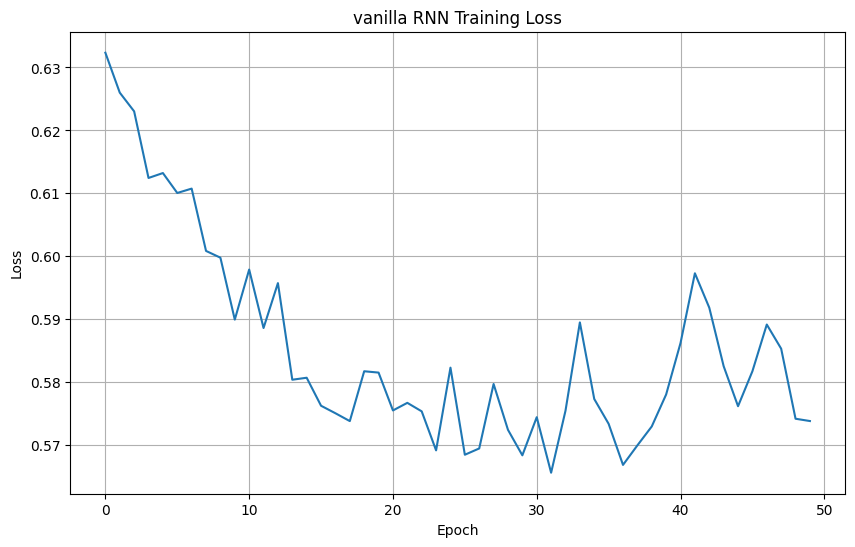

In [13]:
# Your plot code here

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('vanilla RNN Training Loss')
plt.grid(True)
plt.show()


In [ ]:
for i, loss in enumerate(losses):
    print(f'Epoch {i+1}: {loss:.4f}')

In [ ]:
MAX_LENGTH = 1000

def generate_sample(char_rnn, seed_phrase='Али-Баба ', max_length=MAX_LENGTH, temperature=1.0):
    seed_phrase_lc = seed_phrase.lower()
    x_sequence = [token_to_idx[token] for token in seed_phrase_lc]
    x_sequence = torch.tensor([x_sequence], dtype=torch.int64).to(device)
    hid_state = char_rnn.initial_state(batch_size=1)

    # feed the seed phrase
    for i in range(len(seed_phrase_lc) - 1):
        out, hid_state = char_rnn(x_sequence[:, i:i+1], hid_state)

    # start generating
    for _ in range(max_length - len(seed_phrase_lc)):
        out, hid_state = char_rnn(x_sequence[:, -1:], hid_state)
        p_next = F.softmax(out[:, -1] / temperature, dim=-1).cpu().detach().numpy()[0]
        next_ix = np.random.choice(len(tokens), p=p_next)
        next_ix = torch.tensor([[next_ix]], dtype=torch.int64).to(device)
        x_sequence = torch.cat([x_sequence, next_ix], dim=1)

    return ''.join([tokens[ix] for ix in x_sequence.cpu().numpy()[0]])


In [ ]:
# An example of generated text.
# print(generate_text(length=500, temperature=0.2))
#print(generate_sample(model_VRNN, seed_phrase='Привет, Медвед!', temperature=0.2))
#print(generate_sample(model_VRNN, seed_phrase='евгений', temperature=0.2))
print(generate_sample(model_VRNN, seed_phrase='Привет, Медвед!', temperature=0.2, max_length=150))
print("\n" + "=" * 60)
print(generate_sample(model_VRNN, seed_phrase='Друзья Людмилы и Руслана!', temperature=0.2, max_length=150))

### More poetic model

Let's use LSTM instead of vanilla RNN and compare the results.

Plot the loss function of the number of epochs. Does the final loss become better?

In [10]:
# Your beautiful code here

# LSTM
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super(CharLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden

    def initial_state(self, batch_size):
        h0 = torch.zeros(1, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(1, batch_size, self.hidden_size).to(device)
        return (h0, c0)

# экземплдяр LSTM
model_lstm = CharLSTM(vocab_size, HIDDEN_SIZE).to(device)
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=LEARNING_RATE)
criterion_lstm = nn.CrossEntropyLoss()


In [11]:
#from tqdm.notebook import tqdm
import sys
from io import StringIO
from collections import deque
from tqdm import tqdm

# обучение LSTM
losses_lstm = []

epoch_pbar = tqdm(range(NUM_EPOCHS), desc='Epochs', file=buf, ascii=False, postfix={})

for epoch in epoch_pbar:

    sys.stdout.write(buf.get_last_line()+'\n')

    epoch_losses = []

    batch_pbar = tqdm(range(batches_per_epoch), desc=f'Epoch {epoch+1}', file=buf, ascii=False, leave=False)

    for _ in batch_pbar:

        s = buf.get_last_line(-1)
        if s == "\x1b[A":
             s = buf.get_last_line(-2)
        #sys.stdout.write("\n====\n")
        if len(s) > 0:
            #sys.stdout.write(f'{repr(s)}')
            sys.stdout.write(f'{s}')
        else:
            sys.stdout.write(f's is empty')

        x, y = get_batch(data, SEQ_LENGTH, BATCH_SIZE)

        optimizer_lstm.zero_grad()
        hidden = model_lstm.initial_state(BATCH_SIZE)
        output, hidden = model_lstm(x, hidden)

        loss = criterion_lstm(output.view(-1, vocab_size), y.view(-1))
        loss.backward()
        optimizer_lstm.step()

        epoch_losses.append(loss.item())

        batch_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    epoch_pbar.set_postfix({'avg_loss': f'{avg_loss:.4f}'})

    avg_loss = np.mean(epoch_losses)
    losses_lstm.append(avg_loss)

Epochs:   0%|          | 0/50 [00:00<?, ?it/s]


NameError: name 'batches_per_epoch' is not defined

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(losses, label='vanilla RNN')
plt.plot(losses_lstm, label='LSTM')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN vs LSTM Training Loss')
plt.legend()
plt.grid(True)
plt.show()

print(f'Final RNN Loss: {losses[-1]:.4f}')
print(f'Final LSTM Loss: {losses_lstm[-1]:.4f}')

In [ ]:
#for i, loss in enumerate(losses_lstm):
#    print(f'Epoch {i+1}: {loss:.4f}')

In [ ]:
print(generate_sample(model_lstm, seed_phrase='Привет, Бобёр!', temperature=0.2, max_length=150))
print("\n" + "=" * 60)
print(generate_sample(model_lstm, seed_phrase='Друзья Людмилы и Руслана!', temperature=0.2, max_length=300))

Generate text using the trained net with different `temperature` parameter: `[0.1, 0.2, 0.5, 1.0, 2.0]`.

Evaluate the results visually, try to interpret them.

In [ ]:
# Text generation with different temperature values here

temperatures = [0.1, 0.2, 0.5, 1.0, 2.0]

print("=" * 60)
print("VANILLA RNN")
print("=" * 60)
for temp in temperatures:
    print(f"\n--- Temperature: {temp} ---")
    print(generate_sample(model_VRNN, seed_phrase='Друзья Людмилы и Светланы,', temperature=temp, max_length=100))

print("\n" + "=" * 60)
print("LSTM")
print("=" * 60)
for temp in temperatures:
    print(f"\n--- Temperature: {temp} ---")
    print(generate_sample(model_lstm, seed_phrase='Друзья Людмилы и Светланы,', temperature=temp, max_length=150))

### Saving and loading models

Save the model to the disk, then load it and generate text. Examples are available [here](https://pytorch.org/tutorials/beginner/saving_loading_models.html]).

In [ ]:
# Saving and loading code here

# сохранение
torch.save(model_VRNN.state_dict(), 'model_rnn.pth')
torch.save(model_lstm.state_dict(), 'model_lstm.pth')
print('Модели сохранены!')

# загрузка
loaded_rnn = CharRNN(vocab_size, HIDDEN_SIZE).to(device)
loaded_rnn.load_state_dict(torch.load('model_rnn.pth'))
loaded_rnn.eval()

loaded_lstm = CharLSTM(vocab_size, HIDDEN_SIZE).to(device)
loaded_lstm.load_state_dict(torch.load('model_lstm.pth'))
loaded_lstm.eval()
print('Модели загружены!')

# проверка
print("\n" + "=" * 60)
print('\nГенерация из загруженной RNN:')
print("=" * 60)
print(generate_sample(loaded_rnn, seed_phrase='герой романа', temperature=0.5, max_length=300))

print("\n" + "=" * 60)
print('\nГенерация из загруженной LSTM:')
print("=" * 60)
print(generate_sample(loaded_lstm, seed_phrase='герой романа', temperature=0.5, max_length=300))

### References
1. <a href='http://karpathy.github.io/2015/05/21/rnn-effectiveness/'> Andrew Karpathy blog post about RNN. </a>
There are several examples of genration: Shakespeare texts, Latex formulas, Linux Sourse Code and children names.
2. <a href='https://github.com/karpathy/char-rnn'> Repo with char-rnn code </a>
3. Cool repo with PyTorch examples: [link](https://github.com/spro/practical-pytorch`)